# Alternative Uses Task (AUT) Analysis 

**Study:** Influence of abstract spatial massing on creativity in CAD environments


### Contents:

**0. Setup**

**1. Cleaning the data**

**2. Formatting the data**

**3. Building the analysis table**

**4. Turning each model into standardised images**

**5. The three AUT measures**

**6. Paired A vs B comparison** - the primary analysis.

**7. Self-report, stop reasons, time on task.**

**8. Sources**

## 0. Setup

In [1]:
# Installing packages
%pip install -q pandas numpy scipy seaborn matplotlib pingouin statsmodels Pillow

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import json
import sys
import struct
import shutil
import random
import subprocess
import textwrap
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from statsmodels.stats.multitest import multipletests

### Shortcut names used throughout the codebook

File locations are given short names to avoid repeating long paths throughout the notebook.

In [2]:
# Path.cwd() is wherever Jupyter was launched, not where this notebook sits, so walk up
# until the folder holding "Raw Data" is found.
PROJECT = Path.cwd()
while not (PROJECT / "Raw Data").exists() and PROJECT != PROJECT.parent:
    PROJECT = PROJECT.parent

DATA_DIR = PROJECT / "Raw Data" / "Data Capstone DO NOT TOUCH"
RATINGS_DIR = PROJECT / "Raw Data" / "Originality Judges Scores"
SUPPORT = PROJECT / "Supporting Files"
RENDER_DIR = SUPPORT / "renders"
MANIFEST_FILE = RENDER_DIR / "render_manifest.csv"
KEY_FILE = SUPPORT / "originality_key.csv"
SCORES_FILE = SUPPORT / "originality_scores.csv"
FIG_DIR = SUPPORT / "figures"

FIG_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_DIR.exists(), f"Raw Data not found from {Path.cwd()} - start Jupyter inside the project folder"
print(f"project root: {PROJECT}")

project root: /Users/annadoucha/Desktop/🌶️Capstone CODE


In [3]:
# 6 fixed camera angles per model - 4 low diagonals for the silhouette, 2 high ones for the roof
BLENDER_VIEWS = [
    ("V1", 45, 25), ("V2", 135, 25), ("V3", 225, 25),
    ("V4", 315, 25), ("V5", 45, 60), ("V6", 225, 60),
]
VIEW_NAMES = [f"{n}_{az}az_{el}el" for n, az, el in BLENDER_VIEWS]

In [4]:
# seeds + plot style so re-runs match
random.seed(42)
np.random.seed(42)
sns.set_theme(style="whitegrid", palette="muted")

## 1. Cleaning the data

Data collection produced 34 session folders. With the assistance of an LLM, two sessions were identified for exclusion:

- **Participant 12** - excluded as a pilot session due to an outdated data format and inconsistencies between the session and model files.

- **Participant 15** - excluded as a duplicate of Participant 13, with matching participant IDs, timestamps, consent data, and GLB files.

This left **32 participants** for analysis.


In [5]:
#the two dropped sessions, see section 1
EXCLUDE_PARTICIPANTS = {
    "Participant 12",  # pilot, old json format
    "Participant 15", # duplicate of 13
}

#one folder never got renamed by the collection app
FOLDER_LABELS = {
    "P-mqs4sp8k-sns87q_2026-06-24T14-17-07-660Z": "Participant 34",
}

## 2. Formatting the data

Before proceeding with analysis, we have to format questionair answers.  

### 2a. Turning questionnaire answers into numbers
Experience and training were collected as ordered choices ("none", "some", "a_lot"). They are mapped to 0, 1, 2 so they can be stored in a table and correlated. 

In [6]:
EXP_MAP = {"none": 0, "some": 1, "a_lot": 2} #quantifying answers to cad experience
TRAINING_MAP = {"none": 0, "some": 1, "yes": 2} #quantifying answers to education level

## 3. Building the analysis table
Each session’s metadata.json records what the participant did. Each idea is classified and added to a table, with one row for each retained idea.

**Idea classification:**

- `banked` → completed → included in the primary analysis

- `unfinished` with parts → partial → excluded from the primary analysis

- `unfinished` with no parts → empty → dropped

In [7]:
def session_dirs(data_dir):
    out = []
    for d in sorted(data_dir.iterdir()):
        if d.is_dir() and any(f for f in d.glob("*.json") if "interest" not in f.name):
            out.append(d)
    return out

In [8]:
# Tables are sorted by participant number
def label_for(p_dir):
    return FOLDER_LABELS.get(p_dir.name, p_dir.name)

# Extracting participant number out of the lable 
def participant_number(label):
    last_word = label.split()[-1]
    if last_word.isdigit():
        return int(last_word)
    else:
        return 999

In [9]:
def load_metadata(p_dir):
    jfiles = [f for f in p_dir.glob("*.json") if "interest" not in f.name]
    return json.loads(jfiles[0].read_text())

In [10]:
#banked = completed, parts but no bank = partial, empty = drop
def classify_idea(idea):
    if idea["status"] == "banked":
        return True, "completed"
    elif idea["parts"] == 0:
        return None, "empty"
    else:
        return False, "partial"

In [11]:
#covariates from the questionnaire json
def covariates_from(d):
    q   = d.get("questionnaire", {})
    exp = q.get("experience", {})
    return {
        "cad_exp": EXP_MAP.get(exp.get("cad")),
        "sculpt_exp": EXP_MAP.get(exp.get("sculpt")),
        "games_exp": EXP_MAP.get(exp.get("games")),
        "training": TRAINING_MAP.get(q.get("training")),
    }

In [12]:
# main ingest loop - one row per kept idea
# TODO: move this into pipeline/ as its own module

def build_long_table():
    rows, anomalies = [], []

    for p_dir in session_dirs(DATA_DIR):
        pname = label_for(p_dir)
        if pname in EXCLUDE_PARTICIPANTS:
            anomalies.append((pname, "excluded"))
            continue
        d = load_metadata(p_dir)

        pid = d["participantId"]
        cov = covariates_from(d)
        q = d.get("questionnaire", {})

        for cond in ["A", "B"]:
            ideas = d["conditions"][cond].get("ideas", [])

            per_cond = q.get("perCondition", {}).get(cond, {})
            stop_reason = per_cond.get("stopReason")

            idea_count = len(ideas)
            for idea in ideas:
                include, classification = classify_idea(idea)
                if include is None:
                    continue
                # glb = p_dir / f"condition{cond}" / f"{idea['name']}.glb"   # old naming, before the pid prefix
                glb = p_dir / f"condition{cond}" / f"{pid}_{idea['name']}.glb"
                rows.append({
                    "participant": pname,
                    "participant_number": participant_number(pname),
                    "participant_id": pid,
                    "condition": cond,
                    "order_position": d["conditionOrder"].index(cond) + 1,
                    "idea_name": idea["name"],
                    "status": idea["status"],
                    "classification": classification,
                    "include_in_primary": include,
                    "parts_json": idea["parts"],
                    "stop_reason": stop_reason,
                    "glb_path": str(glb),
                    "glb_exists": glb.exists(),
                    **cov,
                })

    df = pd.DataFrame(rows)
    df["time_censored"] = df.stop_reason == "not_enough_time"
    df = df.sort_values(['participant_number', 'condition', 'idea_name']).reset_index(drop=True)
    return df, anomalies

In [13]:
#every participant x condition cell, including the zero-idea ones (matters for fluency)
def build_cell_grid():
    cells = []
    for p_dir in session_dirs(DATA_DIR):
        pname = label_for(p_dir)
        if pname in EXCLUDE_PARTICIPANTS:
            continue
        d = load_metadata(p_dir)
        cov = covariates_from(d)
        q = d.get("questionnaire", {})
        for cond in ["A", "B"]:
            per_cond = q.get("perCondition", {}).get(cond, {})
            cells.append({
                "participant": pname,
                "participant_number": participant_number(pname),
                "participant_id": d["participantId"],
                "condition": cond,
                "order_position": d["conditionOrder"].index(cond) + 1,
                "stop_reason": per_cond.get("stopReason"),
                "time_censored": per_cond.get("stopReason") == "not_enough_time",
                **cov,
            })
    grid = pd.DataFrame(cells)
    return grid.sort_values(["participant_number", "condition"]).reset_index(drop=True)

In [14]:
#Running the ingestion
df_long, anomalies = build_long_table()
grid = build_cell_grid()
# print(df_long.head())

print(f"Sessions loaded: {df_long['participant'].nunique()}")
print(f"Grid cells: {len(grid)} (sessions x 2 conditions)")
print(f"Retained ideas: {len(df_long)}")
print(f"  primary: {int(df_long['include_in_primary'].sum())}")
print(f"  partial: {int((~df_long['include_in_primary']).sum())}")
print("\nExclusions and anomalies:")
for name, issue in anomalies:
    print(f"  [{name}] {issue}")

Sessions loaded: 32
Grid cells: 64 (sessions x 2 conditions)
Retained ideas: 247
  primary: 213
  partial: 34

Exclusions and anomalies:
  [Participant 12] excluded
  [Participant 15] excluded


In [15]:
# completed vs partial

primary = df_long[df_long["include_in_primary"]].reset_index(drop=True)
secondary = df_long[~df_long["include_in_primary"]].reset_index(drop=True)

print(f"primary: {len(primary)} ideas")
print(f"secondary: {len(secondary)} partial attempts")
print("\nPrimary ideas per condition:")
print(primary["condition"].value_counts().to_string())

primary: 213 ideas
secondary: 34 partial attempts

Primary ideas per condition:
condition
A    142
B     71


In [16]:
#idea counts per participant per condition
counts = df_long.groupby(["participant", "condition", "include_in_primary"]).size()
counts = counts.unstack("include_in_primary", fill_value=0)
counts = counts.rename(columns={True: "banked", False: "partial"}).reset_index()
display(counts)

include_in_primary,participant,condition,partial,banked
0,Participant 1,A,0,7
1,Participant 1,B,0,2
2,Participant 10,A,0,26
3,Participant 10,B,0,11
4,Participant 11,A,1,6
...,...,...,...,...
57,Participant 7,B,1,0
58,Participant 8,A,0,6
59,Participant 8,B,0,1
60,Participant 9,A,0,4


## 4. Turning each model into standardised images

Elaboration is measured from images, so all models are rendered consistently from 6 fixed angles. Each model is centred and scaled to a bounding-sphere radius of 1, then rendered with an orthographic camera so every model occupies the same proportion of the frame without clipping or size differences. This was done to ensure that the apparent size is consistent and doesn't skew entropy measures.

Rendering is done by Blender, driven by a script this notebook writes to disk. *This is the slow step: about 45 minutes from scratch.Already-rendered ideas are skipped, so re-running is quick.*

This step utilises code from: https://registry.khronos.org/glTF/specs/2.0/glTF-2.0.html and https://docs.blender.org/manual/en/4.5/addons/import_export/scene_gltf2.html

In [17]:
sys.path.append(str(SUPPORT / "pipeline"))
import rendering

VIEW_NAMES = rendering.VIEW_NAMES
manifest = rendering.build_manifest(primary, RENDER_DIR)
print(f"ideas: {len(manifest)} | images: {len(manifest) * len(VIEW_NAMES)}")

ideas: 213 | images: 1278


In [18]:
manifest, render_status = rendering.render(manifest, RENDER_DIR)
print(render_status)

incomplete = manifest[manifest["n_views_saved"] < len(VIEW_NAMES)]
if len(incomplete):
    display(incomplete[["participant", "condition", "idea_name", "n_views_saved"]])

ALL_RENDERED


In [19]:
# qc pass before entropy - no clipping, fill + brightness in range
frames = rendering.frame_report(manifest)
print(f"images: {len(frames)}")
print(f"clipped: {int(frames['clipped'].sum())}")
print(f"fill range: {frames['fill'].min():.3f} - {frames['fill'].max():.3f}")
print(f"intensity: {int(frames['lo'].min())} - {int(frames['hi'].max())}")

images: 1278
clipped: 0
fill range: 0.014 - 0.554
intensity: 63 - 198


---
## 5. AUT measures

Three dimensions of divergent thinking- fluency, elaboration and originality, each computed on completed ideas only.

### 5a. Fluency

**What it is:** how many distinct ideas a participant produced.

**How it is measured here:** a count of banked ideas per participant per condition.
An idea counts once the participant banks it, so this measures ideas generated. A condition where someone banked nothing scores 0 rather than
being treated as missing.

In [20]:
tmp = primary.groupby(["participant", "condition"]).size().reset_index(name="fluency")
fluency = grid.merge(tmp, on=["participant", "condition"], how="left")
fluency["fluency"] = fluency["fluency"].fillna(0).astype(int)
print(f"{len(fluency)} rows for {fluency.participant.nunique()} participants")

64 rows for 32 participants


In [21]:
# Summarising fluency by condition.
display(fluency.groupby("condition")["fluency"]
        .agg(["count", "mean", "std", "min", "max"]).round(2))

,count,mean,std,min,max
condition,,,,,
A,32,4.44,4.86,0,26
B,32,2.22,2.47,0,11


In [22]:
# Ensuring that sessions where participants produced zero ideas are correctly included in the dataset 
zeros = fluency[fluency["fluency"] == 0]
print(f"{len(zeros)} participant x condition cells with no banked ideas:")
display(zeros[["participant", "condition", "stop_reason"]])

10 participant x condition cells with no banked ideas:


,participant,condition,stop_reason
12,Participant 7,A,felt_finished
13,Participant 7,B,hard_to_make
34,Participant 20,A,not_enough_time
35,Participant 20,B,hard_to_make
37,Participant 21,B,hard_to_make
48,Participant 27,A,felt_finished
51,Participant 28,B,not_enough_time
53,Participant 29,B,hard_to_make
55,Participant 30,B,hard_to_make
61,Participant 33,B,hard_to_make


In [23]:
# Identifying sessions where time ran out 
censored = fluency[fluency["time_censored"]]
print(f"{len(censored)} sessions out of time")
display(censored.groupby("condition").size().rename("n_sessions").to_frame())

21 sessions out of time


,n_sessions
condition,
A,15
B,6


### 5b. Elaboration

Elaboration is how developed or worked-out each idea is. Here it is the average Shannon entropy across the six rendered images - higher entropy means more variation in surface shading, i.e. more complex, developed forms. It correlates only weakly with part count (ρ = 0.12), so it seems to capture visual complexity rather than simply the number of components.

In [24]:
#entropy of the shading values across the model surface
def pixel_entropy(values):
    hist, _ = np.histogram(values, bins=256, range=(0, 256))
    p = hist.astype(float)
    p = p[p > 0] / p.sum()
    return float(-np.sum(p * np.log2(p)))

In [25]:
# entropy per view, then averaged into one score per idea
MIN_MODEL_PIXELS = 50 #setting a minimum size threshold for an image to be included in the elaboration calculation

# source: https://arxiv.org/abs/2408.10616
def entropy_per_view(render_dir):
    rd, vals = Path(render_dir), {}
    for vname in VIEW_NAMES:
        img = rd / f"{vname}.png"
        key = f"H_{vname}"
        if not img.exists():
            vals[key] = np.nan
            continue
        a = np.array(Image.open(img).convert("RGBA"))
        mask = a[..., 3] > 128
        grey = np.array(Image.fromarray(a[..., :3]).convert("L"))[mask]
        vals[key] = pixel_entropy(grey) if grey.size > MIN_MODEL_PIXELS else np.nan
    valid = [v for v in vals.values() if not np.isnan(v)]
    vals["n_views_used"] = len(valid)
    vals["elaboration_entropy"] = np.mean(valid) if valid else np.nan
    return vals

In [26]:
# Adding the elaboration columns to the main dataset
elab = pd.DataFrame([entropy_per_view(d) for d in manifest.render_dir])

# drop any entropy columns already present so re-running this cell replaces them
manifest = manifest.drop(columns=elab.columns, errors="ignore")
manifest = pd.concat([manifest.reset_index(drop=True), elab], axis=1)
manifest.to_csv(MANIFEST_FILE, index=False)

print(f"Ideas scored: {len(manifest)}")
print(f"No usable views: {int(manifest.elaboration_entropy.isna().sum())}")
print(f"Parts mismatches: {int((manifest.glb_n_parts != manifest.parts_json).sum())}")

Ideas scored: 213
No usable views: 0
Parts mismatches: 0


In [27]:
# Inserting elaboration back into the primary table
view_cols = [f"H_{v}" for v in VIEW_NAMES]
primary = primary.merge(manifest[["participant", "condition", "idea_name", "elaboration_entropy", "n_views_used", "glb_n_parts"] + view_cols], on=["participant", "condition", "idea_name"], how="left")
print(f"primary now has {primary.shape[1]} columns")

primary now has 27 columns


In [28]:
# Summarising elaboration by condition, and per view.
print("Elaboration entropy by condition:")
display(manifest.groupby("condition")["elaboration_entropy"]
        .agg(["count", "mean", "std", "min", "max"]).round(3))

print("Mean entropy per view (bits):")
display(manifest[view_cols].mean().round(3).rename("mean H").to_frame())

Elaboration entropy by condition:


,count,mean,std,min,max
condition,,,,,
A,142,4.003,0.605,2.826,5.246
B,71,3.713,0.851,1.960,5.477


Mean entropy per view (bits):


,mean H
H_V1_45az_25el,4.612
H_V2_135az_25el,3.641
H_V3_225az_25el,3.624
H_V4_315az_25el,3.787
H_V5_45az_60el,4.131
H_V6_225az_60el,3.641


### 5c. Originality

**What we mean by it:** how novel or unusual an idea is, relative to the others produced.

**Measurement:** the Consensual Assessment Technique- three independent
judges rate every idea from 1 to 7, blind to which condition it came from.

**The rating package.** Judges were sent a single self-contained HTML file
(`Supporting Files/AUT Originality Ranking.html`) with all 213 models embedded in it.
Stimulus numbers were assigned by a seeded shuffle, so the numbering carries no
information about participant, condition or the order ideas were made in, and the app
re-shuffled the presentation order separately for each judge. The data from judges was imported as CSV

In [29]:
# Importing data from judges
files = sorted(RATINGS_DIR.glob("originality_judge*.csv"))
frames = []
for f in files:
    r = pd.read_csv(f)
    r["source_file"] = f.name
    frames.append(r)
ratings = pd.concat(frames, ignore_index=True)

print(f"{ratings.judge_id.nunique()} judges, {len(ratings)} ratings")
display(ratings.groupby("judge_id")["originality"]
        .agg(["count", "mean", "std", "min", "max"]).round(2))

3 judges, 639 ratings


,count,mean,std,min,max
judge_id,,,,,
1,213,3.90,2.04,1,7
2,213,3.05,1.65,1,7
3,213,2.63,1.30,1,6


In [30]:
# Checking whether the three judges consistently rated the originality of the ideas, using Intra-cluster correlation (ICC).
# source: https://youtu.be/16Sa31mbTWE?si=liSgnXUyQQtbee5Q

import pingouin as pg

wide_r = ratings.pivot(index="stimulus_id", columns="judge_id", values="originality").dropna()
long_r = wide_r.reset_index().melt(id_vars="stimulus_id", var_name="judge", value_name="score")
icc = pg.intraclass_corr(data=long_r, targets="stimulus_id", raters="judge", ratings="score").set_index("Type")

print(f"{len(wide_r)} stimuli rated by all {wide_r.shape[1]} judges")
print("\nHow each judge used the scale:")
display(ratings.groupby("judge_id")["originality"].agg(["mean", "std", "min", "max"]).round(2))
print("Rank agreement between judges (Spearman):")
display(wide_r.corr(method="spearman").round(3))

display(icc.loc[["ICC3k", "ICC2k", "ICC3", "ICC2"], ["Description", "ICC", "CI95%", "pval"]].round(3))
print(f"Headline reliability, ICC(3,k) = {icc.loc['ICC3k', 'ICC']:.3f}")

213 stimuli rated by all 3 judges



How each judge used the scale:


,mean,std,min,max
judge_id,,,,
1,3.90,2.04,1,7
2,3.05,1.65,1,7
3,2.63,1.30,1,6


Rank agreement between judges (Spearman):


judge_id,1,2,3
judge_id,,,
1,1.000,0.570,0.314
2,0.570,1.000,0.387
3,0.314,0.387,1.000


,Description,ICC,CI95%,pval
Type,,,,
ICC3k,Average fixed raters,0.670,"[0.58, 0.74]",0.0
ICC2k,Average random raters,0.621,"[0.48, 0.72]",0.0
ICC3,Single fixed raters,0.404,"[0.32, 0.49]",0.0
ICC2,Single random raters,0.353,"[0.23, 0.46]",0.0


Headline reliability, ICC(3,k) = 0.670


In [31]:
# Checking whether the three judges consistently rated the originality of the ideas, using x-score.
# source: https://youtu.be/16Sa31mbTWE?si=liSgnXUyQQtbee5Q

usable_ratings = ratings.dropna(subset=["originality"])
usable_ratings = usable_ratings[usable_ratings["flagged"] != 1]

print(f"usable ratings: {len(usable_ratings)} of {len(ratings)}")

usable ratings: 639 of 639


In [32]:
# each judge's own average and spread
judge_mean = usable_ratings.groupby("judge_id")["originality"].mean()
judge_sd = usable_ratings.groupby("judge_id")["originality"].std(ddof=0)

display(pd.DataFrame({"mean": judge_mean, "sd": judge_sd}).round(2))

,mean,sd
judge_id,,
1,3.90,2.04
2,3.05,1.65
3,2.63,1.30


In [33]:
# attach them to every row, then convert that row's rating to a z-score
scored = usable_ratings.copy()
scored["judge_mean"] = scored["judge_id"].map(judge_mean)
scored["judge_sd"] = scored["judge_id"].map(judge_sd)
scored["z_score"] = (scored["originality"] - scored["judge_mean"]) / scored["judge_sd"]

display(scored[["judge_id", "stimulus_id", "originality", "judge_mean", "judge_sd", "z_score"]].head(3).round(3))

,judge_id,stimulus_id,originality,judge_mean,judge_sd,z_score
0,1,stimulus_001,4,3.897,2.039,0.051
1,1,stimulus_002,1,3.897,2.039,-1.421
2,1,stimulus_003,2,3.897,2.039,-0.930


In [34]:
# average the judges together, one row per idea
per_idea = scored.groupby("stimulus_id").agg(
    originality_raw=("originality", "mean"),
    originality=("z_score", "mean"),
    n_judges=("judge_id", "nunique"),
).reset_index()

print(f"ideas scored: {len(per_idea)} | judges per idea: {sorted(per_idea['n_judges'].unique())}")

ideas scored: 213 | judges per idea: [np.int64(3)]


In [35]:
# attach each idea back to its participant and condition
key = pd.read_csv(KEY_FILE)
originality = key.merge(per_idea, on="stimulus_id", how="left")

print("Originality (z-scored, averaged across judges) by condition:")
display(originality.groupby("condition")["originality"].agg(["count", "mean", "std"]).round(3))

Originality (z-scored, averaged across judges) by condition:


,count,mean,std
condition,,,
A,142,0.146,0.760
B,71,-0.291,0.742


### How much did the judges agree?
This section examines how consistently the judges rated the ideas and how each judge used the 1–7 rating scale. This helps explain the overall ICC(3,k) agreement score.

In [36]:
# Calculating pairwise agreement between judges
wide_r = ratings.pivot(index="stimulus_id", columns="judge_id", values="originality").dropna()
rho = wide_r.corr(method="spearman")

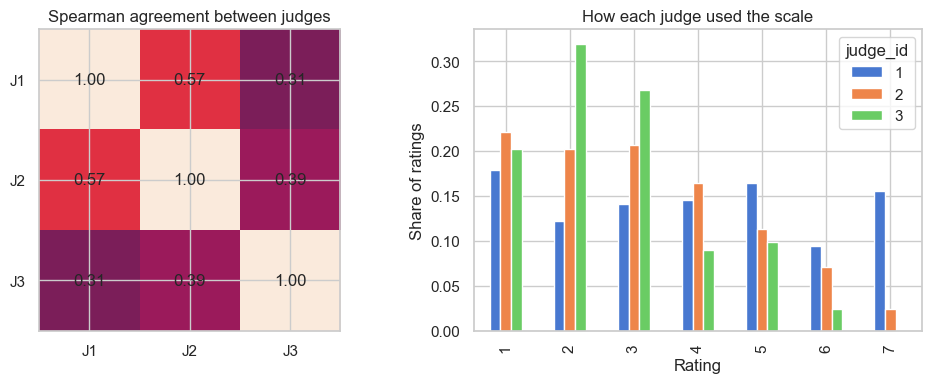

In [37]:
# Plotting judge agreement and how each judge used the rating scale
# source: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax = axes[0]
im = ax.imshow(rho.values, vmin=0, vmax=1)
ax.set_xticks(range(len(rho)))
ax.set_xticklabels([f"J{c}" for c in rho.columns])
ax.set_yticks(range(len(rho)))
ax.set_yticklabels([f"J{c}" for c in rho.index])
for i in range(len(rho)):
    for j in range(len(rho)):
        ax.text(j, i, f"{rho.values[i, j]:.2f}", ha="center", va="center")
ax.set_title("Spearman agreement between judges")
counts = ratings.groupby(["judge_id", "originality"]).size().unstack(fill_value=0).reindex(columns=range(1, 8), fill_value=0)
share = counts.div(counts.sum(axis=1), axis=0)
ax2 = axes[1]
share.T.plot(kind="bar", ax=ax2)
ax2.set_xlabel("Rating")
ax2.set_ylabel("Share of ratings")
ax2.set_title("How each judge used the scale")
plt.tight_layout()
plt.savefig(FIG_DIR / "judge_agreement.png", dpi=150)
plt.show()

---
## 6. Paired A vs B comparison
This analysis compares performance between Conditions A and B for the three main measures: fluency, originality, and elaboration. As each participant completed both conditions, paired analyses were used to compare performence within participants. All tests were two-tailed, with statistical significance set at α = .05.

In [38]:
# wide table - one row per participant x condition
wide = fluency.copy()

elab_by_cell = manifest.groupby(["participant", "condition"])["elaboration_entropy"].mean().reset_index(name="mean_elaboration")
wide = wide.merge(elab_by_cell, on=["participant", "condition"], how="left")

orig_by_cell = originality.groupby(["participant", "condition"])["originality"].mean().reset_index(name="mean_originality")
wide = wide.merge(orig_by_cell, on=["participant", "condition"], how="left")

first_cond = wide[wide.order_position == 1][["participant", "condition"]].rename(columns={"condition": "first_condition"})
wide = wide.merge(first_cond, on="participant", how="left")

MEASURES = ["fluency", "mean_elaboration", "mean_originality"] #creating a list of the measures that will be analysed

In [39]:
# Preparing each measure for paired analysis by matching each participant’s Condition A and Condition B scores and removing incomplete pairs.
def paired_diff(wide, measure):
    p = wide.pivot(index="participant", columns="condition", values=measure).dropna()
    return p["A"].values, p["B"].values, p

### 6.1 Significance test

For all three measures, differences between conditions A and B are tested using a paired, two-tailed Wilcoxon signed-rank test. This test is used consistently because, unlike the paired t-test, its assumptions are met across all three outcomes. While the differences for elaboration and originality are approximately normal, fluency is strongly skewed (Shapiro–Wilk p = .00001), making the t-test unsuitable across the full analysis. The Wilcoxon test avoids this normality assumption, although with a small loss of power where normality does hold. Finally, because three outcomes are tested, Holm–Bonferroni correction is applied to control the overall risk of false positives.

In [ ]:
# running Wilcoxon signed-rank on each measure, then correcting with Holm
rows = []
for measure in MEASURES:
    a, b, paired = paired_diff(wide, measure)
    differences = a - b
    w_statistic, p_value = stats.wilcoxon(a, b)
    rows.append({
        "measure": measure,
        "n_pairs": len(paired),
        "median_A": round(np.median(a), 3),
        "median_B": round(np.median(b), 3),
        "W": w_statistic,
        "p": p_value,
        "ties_dropped": int((differences == 0).sum()),
    })

tests = pd.DataFrame(rows).set_index("measure")

reject, holm_p, _, _ = multipletests(tests["p"], method="holm")
tests["holm_p"] = holm_p
tests["significant"] = reject
display(tests.round(5))

,n_pairs,median_A,median_B,W,p,ties_dropped,holm_p,significant
measure,,,,,,,,
fluency,32,3.000,2.000,10.0,0.00009,9,0.00026,True
mean_elaboration,24,4.060,3.785,77.0,0.03665,0,0.03665,True
mean_originality,24,0.244,-0.207,54.0,0.00481,0,0.00962,True


### 6.2 Visualisation

In [41]:
# Setting up the measures for figure 
LABELS = {
    "fluency": "Fluency\n(ideas banked)",
    "mean_originality": "Originality\n(3 blinded judges)",
    "mean_elaboration": "Elaboration\n(image entropy)"
}
ORDER = [m for m in LABELS if m in MEASURES]

In [42]:
# dz + 95% CI for each measure
rows = []
for m in ORDER:
    a, b, _ = paired_diff(wide, m)
    d = a - b
    n = len(d)
    dz = d.mean() / d.std(ddof=1)
    lo, hi = pg.compute_esci(stat=dz, nx=n, ny=n, paired=True, eftype="cohen")
    rows.append({"measure": m, "n": n, "dz": dz, "lo": lo, "hi": hi})
eff = pd.DataFrame(rows)
display(eff.round(3))

,measure,n,dz,lo,hi
0,fluency,32,0.698,0.30,1.10
1,mean_originality,24,0.499,0.05,0.95
2,mean_elaboration,24,0.400,-0.04,0.84


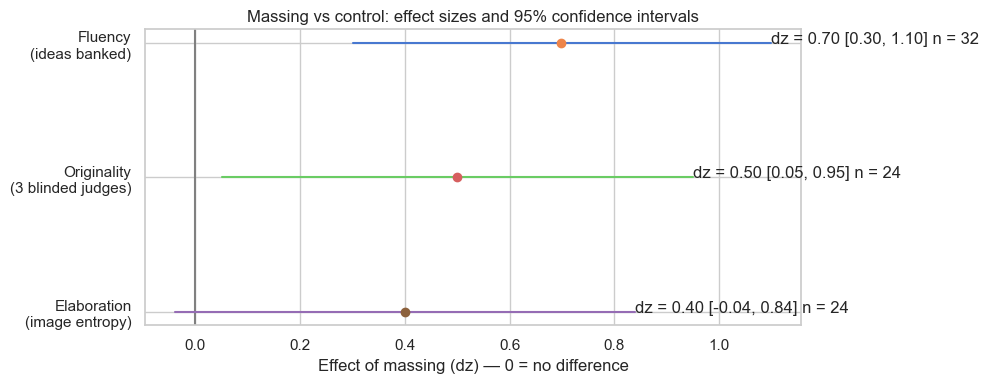

In [43]:
# Plotting effect sizes and 95% confidence intervals.
fig, ax = plt.subplots(figsize=(10, 4))
y = np.arange(len(eff))[::-1]
ax.axvline(0, color="gray")
for yi, r in zip(y, eff.itertuples()):
    ax.plot([r.lo, r.hi], [yi, yi])
    ax.plot(r.dz, yi, "o")
    ax.text(r.hi, yi, f"dz = {r.dz:.2f} [{r.lo:.2f}, {r.hi:.2f}] n = {r.n}")
ax.set_yticks(y)
ax.set_yticklabels([LABELS[m] for m in eff["measure"]])
ax.set_xlabel("Effect of massing (dz) — 0 = no difference")
ax.set_title("Massing vs control: effect sizes and 95% confidence intervals")
plt.tight_layout()
plt.savefig(FIG_DIR / "headline_effects.png", dpi=150)
plt.show()

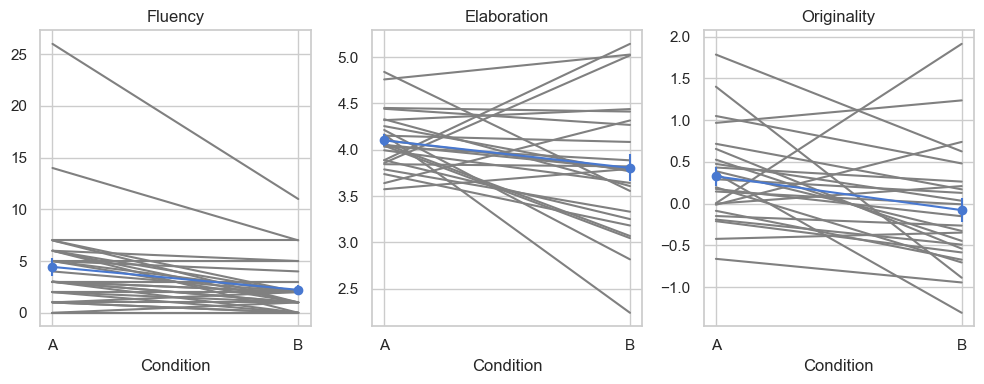

In [44]:
# Plotting each measure as paired participant lines with the condition means
fig, axes = plt.subplots(1, len(MEASURES), figsize=(10, 4))
for ax, measure in zip(axes, MEASURES):
    p = wide.pivot(index="participant", columns="condition", values=measure).dropna()
    for _, row in p.iterrows():
        ax.plot(["A", "B"], [row["A"], row["B"]], color="gray")
    ax.errorbar(["A", "B"], p.mean(), yerr=p.sem(), fmt="o-")
    ax.set_title(measure.replace("mean_", "").replace("_", " ").title())
    ax.set_xlabel("Condition")
plt.tight_layout()
plt.savefig(FIG_DIR / "paired_comparison.png", dpi=150)
plt.show()

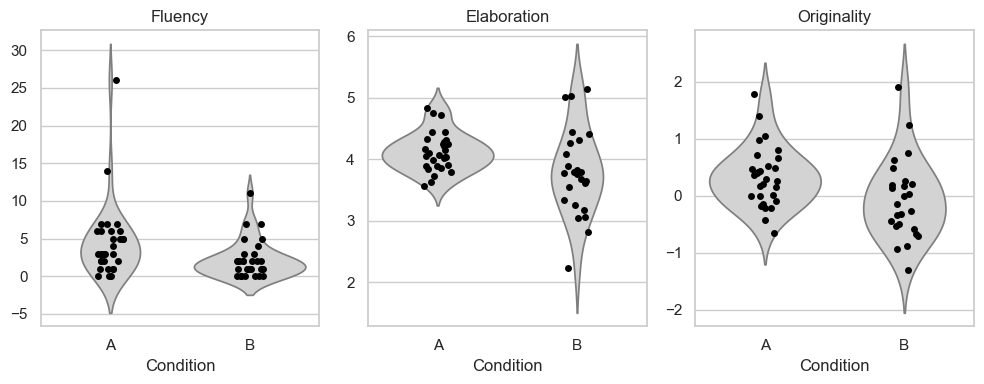

In [45]:
# Plotting the distribution of each measure by condition
fig, axes = plt.subplots(1, len(MEASURES), figsize=(10, 4))
for ax, measure in zip(axes, MEASURES):
    d = wide[["condition", measure]].dropna()
    sns.violinplot(data=d, x="condition", y=measure, inner=None, color="lightgray", ax=ax)
    sns.stripplot(data=d, x="condition", y=measure, color="black", ax=ax)
    ax.set_title(measure.replace("mean_", "").replace("_", " ").title())
    ax.set_xlabel("Condition")
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "distributions.png", dpi=150)
plt.show()

---
## 7. Covariates

This section examines participants’ questionaire responses related to their experience of each condition, including how they felt, why they stopped, and how long they worked, to check whether the fluency difference could simply reflect working faster.

Declaration: A large language model was consulted during the statistical analysis to help select appropriate tests, guided by an established statistical test selection flowchart 

### 7a. Self-report and stop reasons
Extracting Likert responses (1–5) and stop reasons for each participant and condition. The four questionnaire items were compared between conditions using paired Wilcoxon signed-rank tests, with p-values adjusted for multiple comparisons.

In [46]:
# extracting likert scores  and stop reasons for each participant and condition
LIKERT_MAP = {"strongly_disagree": 1, "disagree": 2, "neutral": 3,
              "agree": 4, "strongly_agree": 5}
LIKERT_ITEMS = ["new_possibilities", "surprised", "pictured", "effort_on_design"]

rows = []
for p_dir in session_dirs(DATA_DIR):
    pname = label_for(p_dir)
    if pname in EXCLUDE_PARTICIPANTS:
        continue
    q = load_metadata(p_dir).get("questionnaire", {})
    for cond in ["A", "B"]:
        per_cond = q.get("perCondition", {}).get(cond, {})
        row = {"participant": pname, "condition": cond,
               "stop_reason": per_cond.get("stopReason")}
        for k, v in (per_cond.get("likert") or {}).items():
            row[k] = LIKERT_MAP.get(v)
        rows.append(row)
self_report = pd.DataFrame(rows)

print(f"{len(self_report)} rows, {self_report.participant.nunique()} participants")
print("missing values per item:")
print(self_report[LIKERT_ITEMS].isna().sum().to_string())

64 rows, 32 participants
missing values per item:
new_possibilities    0
surprised            0
pictured             0
effort_on_design     0


In [47]:
# Comparing the four self-report items between conditions using paired Wilcoxon tests
rows = []
for item in LIKERT_ITEMS:
    w = self_report.pivot(index="participant", columns="condition", values=item).dropna()
    d = w["A"] - w["B"]
    res = pg.wilcoxon(w["A"], w["B"])
    rows.append({"item": item, "n": len(w),
                 "mean_A": round(w["A"].mean(), 2), "mean_B": round(w["B"].mean(), 2),
                 "mean_diff": round(d.mean(), 2), "rank_biserial": round(res["RBC"].iloc[0], 3),
                 "p": res["p-val"].iloc[0], "ties": int((d == 0).sum())})

likert_results = pd.DataFrame(rows).set_index("item")

In [48]:
# adjusting the p-values for multiple comparisons using the Holm correction.
from statsmodels.stats.multitest import multipletests
rej, p_holm, _, _ = multipletests(likert_results.p, method="holm")
likert_results["holm_p"] = p_holm
likert_results["significant"] = rej
display(likert_results.round(5))

,n,mean_A,mean_B,mean_diff,rank_biserial,p,ties,holm_p,significant
item,,,,,,,,,
new_possibilities,32,3.91,2.91,1.00,0.858,0.00035,10,0.00142,True
surprised,32,3.72,3.12,0.59,0.489,0.03595,9,0.03595,True
pictured,32,3.38,2.25,1.12,0.870,0.00042,11,0.00142,True
effort_on_design,32,3.38,1.94,1.44,0.807,0.00051,8,0.00142,True


In [49]:
# comparing participants' reasons for stopping between conditions using a chi-square test.
stop_table = pd.crosstab(self_report.stop_reason, self_report.condition)
stop_table["A_%"] = (stop_table["A"] / stop_table["A"].sum() * 100).round(1)
stop_table["B_%"] = (stop_table["B"] / stop_table["B"].sum() * 100).round(1)
display(stop_table)

chi2, p_chi, dof, _ = stats.chi2_contingency(stop_table[["A", "B"]])
print(f"chi-square = {chi2:.3f}, df = {dof}, p = {p_chi:.5f}")

condition,A,B,A_%,B_%
stop_reason,,,,
felt_finished,7,4,21.9,12.5
hard_to_make,8,17,25.0,53.1
not_enough_time,15,6,46.9,18.8
out_of_ideas,2,5,6.2,15.6


chi-square = 9.201, df = 3, p = 0.02673


In [50]:
# comparing stop reasons between conditions within each participant using McNemar's test
from statsmodels.stats.contingency_tables import mcnemar
switched = self_report.pivot(index="participant", columns="condition", values="stop_reason").dropna()
out = []
for reason in ["not_enough_time", "hard_to_make", "out_of_ideas", "felt_finished"]:
    A = switched["A"].eq(reason)
    B = switched["B"].eq(reason)
    only_A = (A & ~B).sum()
    only_B = (~A & B).sum()
    res = mcnemar([[0, only_A], [only_B, 0]], exact=True)
    out.append({"reason": reason, "only_A": only_A, "only_B": only_B, "p": res.pvalue})
display(pd.DataFrame(out).set_index("reason"))

,only_A,only_B,p
reason,,,
not_enough_time,13,4,0.049042
hard_to_make,5,14,0.063568
out_of_ideas,0,3,0.250000
felt_finished,7,4,0.548828


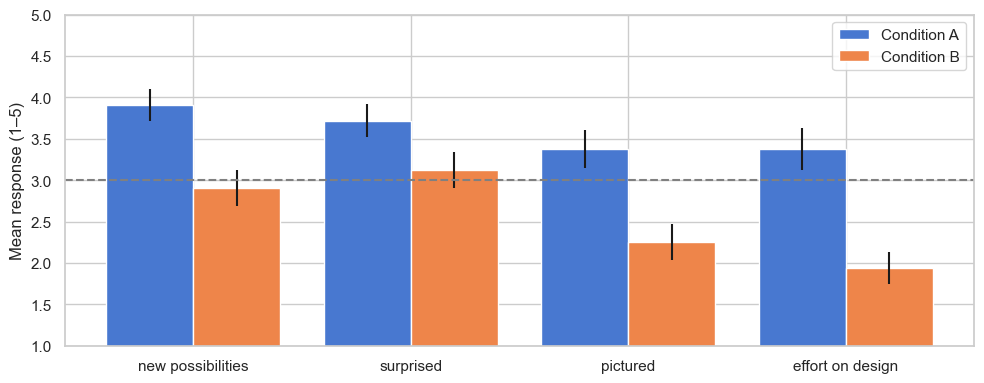

In [51]:
# plotting mean self-report responses by condition with standard error bars
means = self_report.groupby("condition")[LIKERT_ITEMS].mean()
sems = self_report.groupby("condition")[LIKERT_ITEMS].sem()
x = np.arange(len(LIKERT_ITEMS))
fig, ax = plt.subplots(figsize=(10, 4))
for offset, condition in [(-0.2, "A"), (0.2, "B")]:
    ax.bar(x + offset, means.loc[condition], 0.4, yerr=sems.loc[condition], label=f"Condition {condition}")
ax.set_xticks(x)
ax.set_xticklabels([item.replace("_", " ") for item in LIKERT_ITEMS])
ax.set_ylabel("Mean response (1–5)")
ax.set_ylim(1, 5)
ax.axhline(3, color="gray", linestyle="--")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "self_report.png", dpi=150)
plt.show()

### 7b. Time on task
The fluency result raises a key question: did massing produce more ideas, or did participants simply work faster? To check this, we'll look at session timestamps to estimate time spent in each condition and calculate an ideas-per-minute rate.

In [52]:
# calculating the time each participant spent in each condition from the session timestamps
rows = []
for p_dir in session_dirs(DATA_DIR):
    participant = label_for(p_dir)
    if participant in EXCLUDE_PARTICIPANTS:
        continue
    data = load_metadata(p_dir)
    start = pd.to_datetime(data["startedAt"])
    order = data["conditionOrder"]
    tA = pd.to_datetime(data["conditions"]["A"]["receivedAt"])
    tB = pd.to_datetime(data["conditions"]["B"]["receivedAt"])
    times = {"A": tA, "B": tB}
    first = order[0]
    second = order[1]
    rows.append({"participant": participant, "condition": first, "slot": "first",
                 "minutes": (times[first] - start).total_seconds() / 60})
    rows.append({"participant": participant, "condition": second, "slot": "second",
                 "minutes": (times[second] - times[first]).total_seconds() / 60})
time_on_task = pd.DataFrame(rows)

display(time_on_task["minutes"].describe(percentiles=[.05, .5, .95]).round(1).to_frame("minutes"))

,minutes
count,64.0
mean,28.2
std,138.3
min,2.6
5%,2.6
50%,10.8
95%,25.4
max,1113.3


In [53]:
# wide minutes table, dropping sessions with implausible durations (left open overnight etc)
t = time_on_task.pivot(index="participant", columns="condition", values="minutes")
t_ok = t[(t > 0).all(axis=1) & (t < 60).all(axis=1)].dropna()
print(f"kept {len(t_ok)} of {len(t)} participants")


kept 30 of 32 participants


In [54]:
# comparing time spnt in Conditions A and B
d = (t_ok["A"] - t_ok["B"]).values
_, p_time = stats.wilcoxon(d)

print(f"median minutes, massing (A): {t_ok['A'].median():.1f}")
print(f"median minutes, control (B): {t_ok['B'].median():.1f}")
print(f"median difference: {np.median(d):+.1f}")
print(f"Wilcoxon p: {p_time:.4f}")

median minutes, massing (A): 10.5
median minutes, control (B): 10.9
median difference: +0.2
Wilcoxon p: 0.7303


In [55]:
# comparing ideas produced per minute between Conditions A and B
banked = primary.groupby(["participant", "condition"]).size().unstack(fill_value=0)
banked = banked.reindex(t_ok.index)
rate = (banked / t_ok).dropna()

_, p_rate = stats.wilcoxon(rate["A"] - rate["B"])

print(f"n = {len(rate)}")
print(f"Median ideas/min A: {rate['A'].median():.2f}")
print(f"Median ideas/min B: {rate['B'].median():.2f}")
print(f"Wilcoxon p: {p_rate:.5f}")

n = 28
Median ideas/min A: 0.44
Median ideas/min B: 0.18
Wilcoxon p: 0.00011


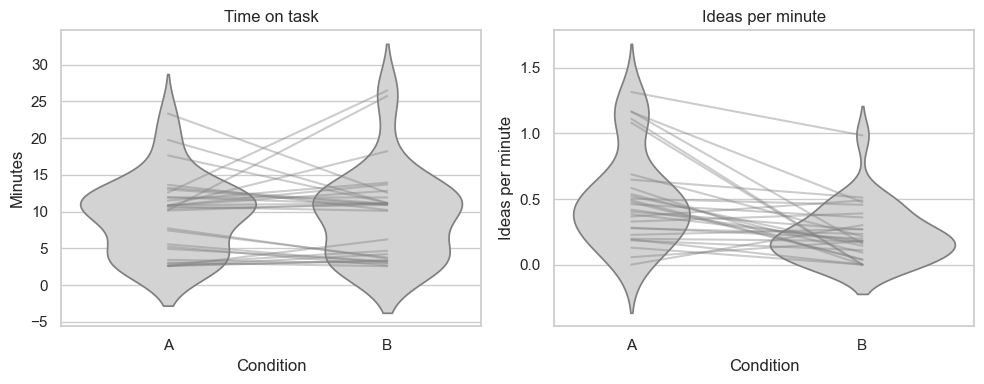

In [56]:
# plotting time on task and ideas per minute by condition
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, data, title, ylabel in [(axes[0], t_ok, "Time on task", "Minutes"),
                                (axes[1], rate, "Ideas per minute", "Ideas per minute")]:
    long = data.reset_index().melt(id_vars="participant", var_name="condition", value_name="value")
    sns.violinplot(data=long, x="condition", y="value", inner=None, color="lightgray", ax=ax)
    for _, row in data.iterrows():
        ax.plot(["A", "B"], [row["A"], row["B"]], color="gray", alpha=0.4)
    ax.set_title(title)
    ax.set_xlabel("Condition")
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.savefig(FIG_DIR / "time_and_rate.png", dpi=150)
plt.show()

## 8. Sources
Sources used to support the code and statistical methods in this analysis:

- [SciPy: Wilcoxon signed-rank test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.wilcoxon.html)

- [SciPy: Paired t-test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_rel.html)

- [SciPy: Shapiro–Wilk test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html)

- [Statsmodels: Holm correction](https://www.statsmodels.org/stable/generated/statsmodels.stats.multitest.multipletests.html)

- [Pingouin: Intraclass correlation (ICC)](https://pingouin-stats.org/generated/pingouin.intraclass_corr.html)

- [SciPy: Binomial test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binomtest.html)

- [SciPy: Spearman correlation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html)

- [scikit-image: Shannon entropy](https://scikit-image.org/docs/stable/api/skimage.measure.html)

- [Blender: Camera API](https://docs.blender.org/api/current/bpy.types.Camera.html)

- [Blender: Render API](https://docs.blender.org/api/current/bpy.ops.render.html)

